# Anomaly Detection for Credit Card Fraud

## Goal

The goal of this notebook is to experiment with anomaly detection models on a highly imbalanced fraud detection dataset.

Instead of training a normal supervised classifier, we treat fraud cases as rare unusual transactions. The models will learn what normal transactions look like and assign anomaly scores to suspicious transactions.

I then use the available labels only for evaluation.

In [1]:
import os
import warnings

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


## Dataset

This dataset contains anonymized credit card transactions. Most features are PCA-transformed variables named `V1` to `V28`, while `Time` and `Amount` are the only original-style numerical features. The target column is `Class`, where `0` means normal transaction and `1` means fraudulent transaction.

This project uses the labels only for evaluation. The anomaly detection models are trained as unsupervised or semi-unsupervised models.

In [2]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Dataset downloaded to:", path)

print("Files in dataset folder:")
print(os.listdir(path))

100%|██████████| 66.0M/66.0M [00:12<00:00, 5.36MB/s]

Extracting files...


Dataset downloaded to: C:\Users\ADMIN\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3
Files in dataset folder:
['creditcard.csv']


In [3]:
csv_path = os.path.join(path, "creditcard.csv")
df = pd.read_csv(csv_path)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print("Shape:", df.shape)
df.info()

Shape: (284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  flo

In [5]:
class_counts = df["Class"].value_counts()
class_ratio = df["Class"].value_counts(normalize=True)

print(class_counts)
print(class_ratio)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


## Initial Data Inspection

The dataset contains 284806 transactions and 30 columns.

The target variable is highly imbalanced. There are 284315 normal transactions and 492 fraud transactions. Fraud cases represent approximately 0.17% of the dataset.

There are 0 missing values.

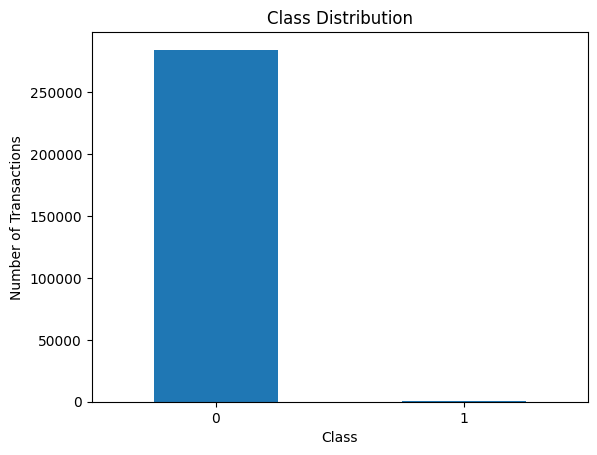

In [6]:
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.show()

In [7]:
fraud_rate = df["Class"].mean()
print(f"Fraud rate: {fraud_rate:.5f}")
print(f"Fraud percentage: {fraud_rate * 100:.4f}%")

Fraud rate: 0.00173
Fraud percentage: 0.1727%


## Class Imbalance

The dataset is extremely imbalanced because fraudulent transactions are very rare compared with normal transactions.

This means accuracy is not a useful evaluation metric. A model could predict every transaction as normal and still achieve very high accuracy, but it would fail the actual purpose of fraud detection.

For this reason, the notebook focuses on metrics such as precision, recall, F1-score, ROC-AUC, PR-AUC, and Precision@K.

In [8]:
normal = df[df["Class"] == 0]
fraud = df[df["Class"] == 1]

print("Normal amount summary:")
print(normal["Amount"].describe())

print("\nFraud amount summary:")
print(fraud["Amount"].describe())

Normal amount summary:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Fraud amount summary:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


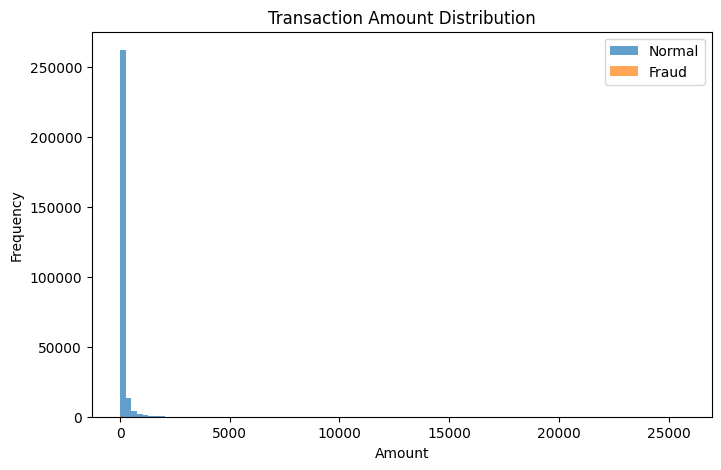

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(normal["Amount"], bins=100, alpha=0.7, label="Normal")
plt.hist(fraud["Amount"], bins=100, alpha=0.7, label="Fraud")
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.legend()
plt.show()

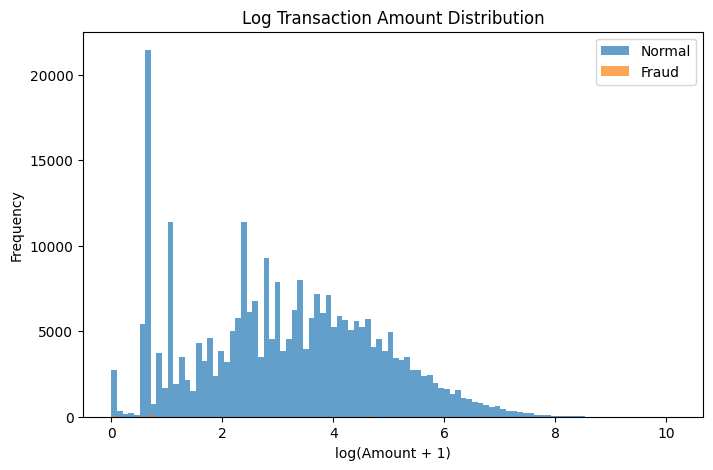

In [10]:
df["LogAmount"] = np.log1p(df["Amount"])

plt.figure(figsize=(8, 5))
plt.hist(df[df["Class"] == 0]["LogAmount"], bins=100, alpha=0.7, label="Normal")
plt.hist(df[df["Class"] == 1]["LogAmount"], bins=100, alpha=0.7, label="Fraud")
plt.title("Log Transaction Amount Distribution")
plt.xlabel("log(Amount + 1)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

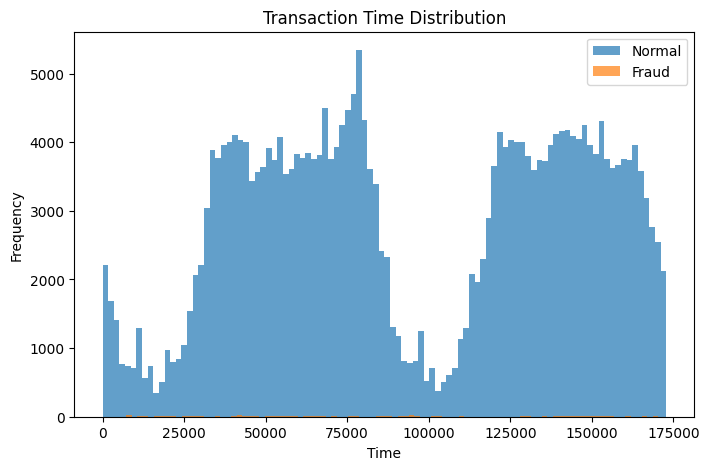

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(df[df["Class"] == 0]["Time"], bins=100, alpha=0.7, label="Normal")
plt.hist(df[df["Class"] == 1]["Time"], bins=100, alpha=0.7, label="Fraud")
plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.legend()
plt.show()

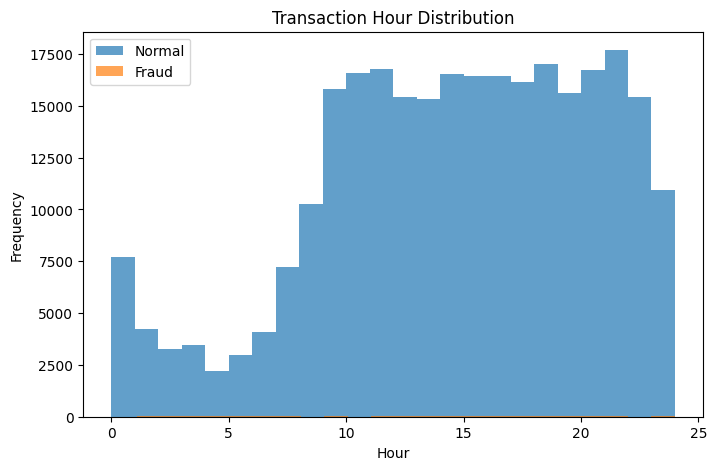

In [12]:
df["Hour"] = (df["Time"] / 3600) % 24

plt.figure(figsize=(8, 5))
plt.hist(df[df["Class"] == 0]["Hour"], bins=24, alpha=0.7, label="Normal")
plt.hist(df[df["Class"] == 1]["Hour"], bins=24, alpha=0.7, label="Fraud")
plt.title("Transaction Hour Distribution")
plt.xlabel("Hour")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Train-Test Setup

The dataset is split into training and testing sets using stratification so that the fraud ratio is preserved.

For anomaly detection, the models are trained mainly on normal transactions. This matches the real-world idea that we often have many examples of normal behaviour but limited examples of fraud.

The fraud labels are kept aside and used only to evaluate whether high anomaly scores correspond to actual fraud cases.

In [13]:
target_col = "Class"

X = df.drop(columns=[target_col])
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (284807, 32)
y shape: (284807,)


In [14]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Train anomaly models mainly on normal transactions
X_train_normal = X_train_full[y_train_full == 0]

print("Full train shape:", X_train_full.shape)
print("Normal-only train shape:", X_train_normal.shape)
print("Test shape:", X_test.shape)
print("Test fraud count:", y_test.sum())

Full train shape: (199364, 32)
Normal-only train shape: (199020, 32)
Test shape: (85443, 32)
Test fraud count: 148


In [15]:
scaler = StandardScaler()

X_train_normal_scaled = scaler.fit_transform(X_train_normal)
X_test_scaled = scaler.transform(X_test)

In [16]:
def evaluate_anomaly_scores(y_true, anomaly_scores, threshold=None, top_k=None):
    """
    Evaluate anomaly scores.
    
    Higher anomaly score means more suspicious.
    
    threshold:
        If provided, classify as fraud when score >= threshold.
        
    top_k:
        If provided, classify the top_k highest-scoring observations as fraud.
    """
    
    roc_auc = roc_auc_score(y_true, anomaly_scores)
    pr_auc = average_precision_score(y_true, anomaly_scores)
    
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC:  {pr_auc:.4f}")
    
    if top_k is not None:
        cutoff = np.sort(anomaly_scores)[-top_k]
        y_pred = (anomaly_scores >= cutoff).astype(int)
        print(f"\nUsing Top-{top_k} threshold")
        
    elif threshold is not None:
        y_pred = (anomaly_scores >= threshold).astype(int)
        print(f"\nUsing fixed threshold: {threshold:.4f}")
        
    else:
        return {
            "roc_auc": roc_auc,
            "pr_auc": pr_auc
        }
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))
    
    return {
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

## Model 1: Isolation Forest

Isolation Forest works by randomly splitting the data. Anomalies are easier to isolate because they are rare and different.

In [17]:
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.0017,  # approximate fraud ratio
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_train_normal_scaled)

,n_estimators,200
,max_samples,'auto'
,contamination,0.0017
,max_features,1.0
,bootstrap,False
,n_jobs,-1
,random_state,42
,verbose,0
,warm_start,False


In [18]:
# decision_function: higher = more normal
# multiply by -1 so higher = more anomalous
iso_scores = -iso_forest.decision_function(X_test_scaled)

iso_results = evaluate_anomaly_scores(y_test, iso_scores)

ROC-AUC: 0.9453
PR-AUC:  0.1058


In [19]:
test_fraud_count = int(y_test.sum())
print("Fraud cases in test set:", test_fraud_count)

iso_topk_results = evaluate_anomaly_scores(
    y_test,
    iso_scores,
    top_k=test_fraud_count
)

Fraud cases in test set: 148
ROC-AUC: 0.9453
PR-AUC:  0.1058

Using Top-148 threshold

Confusion Matrix:
[[85176   119]
 [  119    29]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9986    0.9986    0.9986     85295
           1     0.1959    0.1959    0.1959       148

    accuracy                         0.9972     85443
   macro avg     0.5973    0.5973    0.5973     85443
weighted avg     0.9972    0.9972    0.9972     85443



## Isolation Forest Results

Isolation Forest achieved a ROC-AUC of 0.9453 and a PR-AUC of 0.1058.

When classifying the top 148 most suspicious transactions as fraud, the model found 29 actual fraud cases. This gives a precision of 0.1959, recall of 0.1959, and F1-score of 0.1959 for the fraud class.

The confusion matrix shows that 119 normal transactions were incorrectly flagged as fraud, while 119 fraud transactions were missed.

Overall, Isolation Forest produced a strong ROC-AUC, meaning it can generally rank fraud cases above normal cases. However, the PR-AUC and Top-K results show that detecting fraud precisely is still difficult because the positive class is extremely rare.

## Model 2: Local Outlier Factor

Local Outlier Factor compares each point with its local neighbourhood. A point is suspicious if it looks isolated compared with nearby points.

Important detail: we use novelty=True so that LOF can score new test data.

In [20]:
lof = LocalOutlierFactor(
    n_neighbors=35,
    contamination=0.0017,
    novelty=True,
    n_jobs=-1
)

lof.fit(X_train_normal_scaled)

,n_neighbors,35
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,contamination,0.0017
,novelty,True
,n_jobs,-1


In [21]:
# decision_function: higher = more normal
# multiply by -1 so higher = more anomalous
lof_scores = -lof.decision_function(X_test_scaled)

lof_results = evaluate_anomaly_scores(y_test, lof_scores)

ROC-AUC: 0.9284
PR-AUC:  0.0385


In [22]:
lof_topk_results = evaluate_anomaly_scores(
    y_test,
    lof_scores,
    top_k=test_fraud_count
)

ROC-AUC: 0.9284
PR-AUC:  0.0385

Using Top-148 threshold

Confusion Matrix:
[[85158   137]
 [  137    11]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9984    0.9984    0.9984     85295
           1     0.0743    0.0743    0.0743       148

    accuracy                         0.9968     85443
   macro avg     0.5364    0.5364    0.5364     85443
weighted avg     0.9968    0.9968    0.9968     85443



## Local Outlier Factor Results

Local Outlier Factor achieved a ROC-AUC of 0.9284 and a PR-AUC of 0.0385.

When classifying the top 148 most suspicious transactions as fraud, the model found 11 actual fraud cases. This gives a precision of 0.0743, recall of 0.0743, and F1-score of 0.0743 for the fraud class.

The confusion matrix shows that 137 normal transactions were incorrectly flagged as fraud, while 137 fraud transactions were missed.

Although LOF achieved a reasonably high ROC-AUC, its PR-AUC and Top-K performance were weaker than the other models. This suggests that local density-based anomaly detection was less effective for this dataset.

## Model 3: One-Class SVM

One-Class SVM can be slow on large datasets, so we will use a sample of normal training data.

In [23]:
sample_size = 30000

X_train_normal_sample = X_train_normal.sample(
    n=min(sample_size, len(X_train_normal)),
    random_state=42
)

scaler_svm = StandardScaler()
X_train_svm_scaled = scaler_svm.fit_transform(X_train_normal_sample)
X_test_svm_scaled = scaler_svm.transform(X_test)

In [24]:
oc_svm = OneClassSVM(
    kernel="rbf",
    nu=0.0017,
    gamma="scale"
)

oc_svm.fit(X_train_svm_scaled)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,nu,0.0017
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [25]:
# decision_function: higher = more normal
# multiply by -1 so higher = more anomalous
svm_scores = -oc_svm.decision_function(X_test_svm_scaled)

svm_results = evaluate_anomaly_scores(y_test, svm_scores)

ROC-AUC: 0.9365
PR-AUC:  0.2753


In [26]:
svm_topk_results = evaluate_anomaly_scores(
    y_test,
    svm_scores,
    top_k=test_fraud_count
)

ROC-AUC: 0.9365
PR-AUC:  0.2753

Using Top-148 threshold

Confusion Matrix:
[[85200    95]
 [   95    53]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9989    0.9989    0.9989     85295
           1     0.3581    0.3581    0.3581       148

    accuracy                         0.9978     85443
   macro avg     0.6785    0.6785    0.6785     85443
weighted avg     0.9978    0.9978    0.9978     85443



## One-Class SVM Results

One-Class SVM achieved a ROC-AUC of 0.9365 and a PR-AUC of 0.2753.

When classifying the top 148 most suspicious transactions as fraud, the model found 53 actual fraud cases. This gives a precision of 0.3581, recall of 0.3581, and F1-score of 0.3581 for the fraud class.

The confusion matrix shows that 95 normal transactions were incorrectly flagged as fraud, while 95 fraud transactions were missed.

Compared with Isolation Forest and Local Outlier Factor, One-Class SVM achieved the best PR-AUC and the best Top-K fraud detection performance. This suggests that the non-linear boundary learned by the RBF kernel was useful for separating some fraudulent transactions from normal behaviour.

## Model Comparison

The models are compared using ROC-AUC, PR-AUC, and Top-K metrics.

PR-AUC is especially important because the positive class is extremely rare. In rare-event detection, ROC-AUC can sometimes look strong even when the model is not very useful at finding actual positives.

Top-K evaluation is also practical because in a real fraud system, analysts may only review the most suspicious transactions.

## ROC Curve vs Precision-Recall Curve

The ROC curve shows the trade-off between true positive rate and false positive rate.

The precision-recall curve shows the trade-off between precision and recall. For highly imbalanced data, the precision-recall curve is often more informative because it focuses directly on the minority class.

In this project, PR-AUC is more important than ROC-AUC because fraud cases are rare.

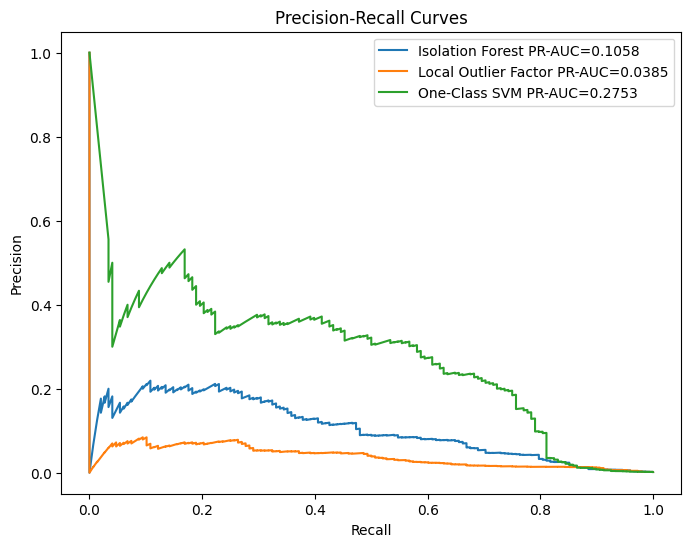

In [27]:
models_scores = {
    "Isolation Forest": iso_scores,
    "Local Outlier Factor": lof_scores,
    "One-Class SVM": svm_scores,
}

plt.figure(figsize=(8, 6))

for model_name, scores in models_scores.items():
    precision, recall, _ = precision_recall_curve(y_test, scores)
    pr_auc = average_precision_score(y_test, scores)
    plt.plot(recall, precision, label=f"{model_name} PR-AUC={pr_auc:.4f}")

plt.title("Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

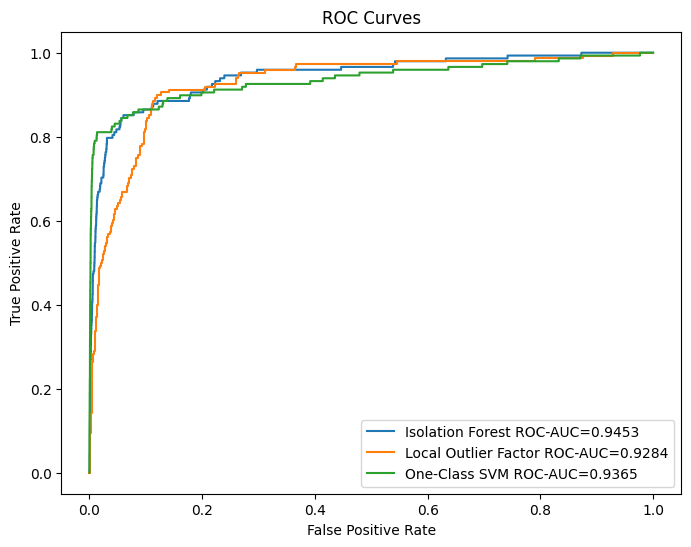

In [28]:
plt.figure(figsize=(8, 6))

for model_name, scores in models_scores.items():
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = roc_auc_score(y_test, scores)
    plt.plot(fpr, tpr, label=f"{model_name} ROC-AUC={roc_auc:.4f}")

plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## Top-Risk Transaction Review

A useful way to evaluate anomaly detection is to inspect the highest-risk transactions.

Instead of only asking whether the model is correct for every transaction, we can ask:

- Are the top suspicious transactions actually enriched with fraud?
- Would this ranking help an analyst prioritize cases?
- Are the top anomalies unusual because of amount, time, or hidden PCA features?

This is closer to how anomaly detection systems may be used in practice.

In [29]:
best_scores = iso_scores
best_model_name = "Isolation Forest"

review_df = X_test.copy()
review_df["Class"] = y_test.values
review_df["AnomalyScore"] = best_scores

top_risk = review_df.sort_values("AnomalyScore", ascending=False).head(20)

top_risk[["Time", "Amount", "Hour", "Class", "AnomalyScore"]]

,Time,Amount,Hour,Class,AnomalyScore
173353,121450.0,4861.64,9.736111,0,0.119716
220090,142019.0,5964.95,15.449722,0,0.108596
219257,141655.0,3502.11,15.348611,0,0.103985
176335,122723.0,1676.60,10.089722,0,0.098498
262839,160669.0,1441.06,20.630278,0,0.093523
201775,134033.0,1402.38,13.231389,0,0.090506
228158,145381.0,8182.70,16.383611,0,0.089526
284249,172273.0,10199.44,23.853611,0,0.086953
229859,146082.0,2687.48,16.578333,0,0.083239
46841,42951.0,12910.93,11.930833,0,0.081624


In [30]:
top_20_fraud_count = top_risk["Class"].sum()
print("Fraud cases in top 20:", top_20_fraud_count)
print("Precision@20:", top_20_fraud_count / 20)

Fraud cases in top 20: 3
Precision@20: 0.15


## Top-Risk Transaction Review

Using Isolation Forest, the top 20 most suspicious transactions contained 3 actual fraud cases. This gives a Precision@20 of 0.15.

This means that 15% of the highest-ranked transactions were truly fraudulent. While this is not perfect, it is much better than the original fraud rate of only 0.1727%.

The top-risk table also shows that many highly ranked transactions were normal transactions with unusually large amounts. For example, several top-ranked normal transactions had amounts above 4,000, 8,000, or even 10,000.

This suggests that Isolation Forest is strongly sensitive to unusual transaction size. However, the presence of normal high-amount transactions in the top-risk list also shows the risk of false positives.

The fraud cases that appeared in the top 20 had very small amounts, such as 1.00 and 2.28. This is useful because it shows that the model is not only detecting large transactions, but also identifying unusual patterns from the hidden PCA features.

In [31]:
def threshold_report(y_true, scores, percentiles):
    rows = []
    
    for p in percentiles:
        threshold = np.percentile(scores, p)
        y_pred = (scores >= threshold).astype(int)
        
        rows.append({
            "Percentile Threshold": p,
            "Alerts": y_pred.sum(),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "F1": f1_score(y_true, y_pred, zero_division=0),
        })
        
    return pd.DataFrame(rows)

thresholds_df = threshold_report(
    y_test,
    best_scores,
    percentiles=[90, 95, 97, 98, 99, 99.5, 99.8, 99.9]
)

thresholds_df

,Percentile Threshold,Alerts,Precision,Recall,F1
0,90.0,8545,0.014980,0.864865,0.029449
1,95.0,4273,0.028317,0.817568,0.054739
2,97.0,2564,0.044072,0.763514,0.083333
3,98.0,1709,0.058514,0.675676,0.107701
4,99.0,855,0.087719,0.506757,0.149551
5,99.5,428,0.130841,0.378378,0.194444
6,99.8,171,0.198830,0.229730,0.213166
7,99.9,86,0.197674,0.114865,0.145299


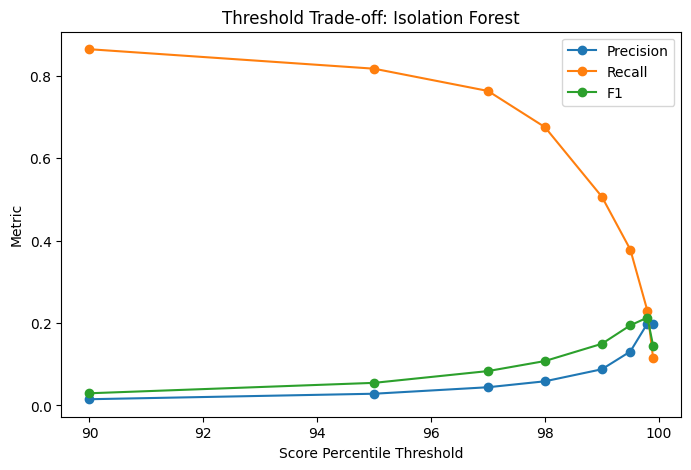

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(thresholds_df["Percentile Threshold"], thresholds_df["Precision"], marker="o", label="Precision")
plt.plot(thresholds_df["Percentile Threshold"], thresholds_df["Recall"], marker="o", label="Recall")
plt.plot(thresholds_df["Percentile Threshold"], thresholds_df["F1"], marker="o", label="F1")
plt.title(f"Threshold Trade-off: {best_model_name}")
plt.xlabel("Score Percentile Threshold")
plt.ylabel("Metric")
plt.legend()
plt.show()

## Threshold Trade-Off

The threshold comparison shows the trade-off between the number of alerts, precision, and recall.

At the 90th percentile threshold, the model flagged 8,545 transactions. This captured 86.49% of fraud cases, but precision was only 1.50%. This means the model caught many fraud cases, but created many false positives.

As the threshold became stricter, the number of alerts decreased and precision improved. At the 99.8th percentile threshold, the model flagged only 171 transactions, with precision of 19.88%, recall of 22.97%, and the highest F1-score of 0.2132 among the tested thresholds.

At the 99.9th percentile threshold, only 86 transactions were flagged. Precision stayed similar at 19.77%, but recall dropped to 11.49%, causing F1-score to decrease.

Based on this threshold table, the 99.8th percentile appears to give the best balance between precision and recall for Isolation Forest in this experiment.

## Synthetic anomaly stress test

This checks whether the model reacts sensibly to artificially unusual transactions.

We create fake transactions by taking normal transactions and multiplying the amount by a large factor.

In [33]:
synthetic = X_test[y_test == 0].sample(1000, random_state=42).copy()
synthetic["Amount"] = synthetic["Amount"] * 10
synthetic["LogAmount"] = np.log1p(synthetic["Amount"])

synthetic_scaled = scaler.transform(synthetic)

synthetic_scores = -iso_forest.decision_function(synthetic_scaled)

print("Original normal score mean:", best_scores[y_test.values == 0].mean())
print("Synthetic anomaly score mean:", synthetic_scores.mean())
print("Original normal score median:", np.median(best_scores[y_test.values == 0]))
print("Synthetic anomaly score median:", np.median(synthetic_scores))

Original normal score mean: -0.2343923795865389
Synthetic anomaly score mean: -0.21836779497427664
Original normal score median: -0.24413514429996286
Synthetic anomaly score median: -0.2267155124547222


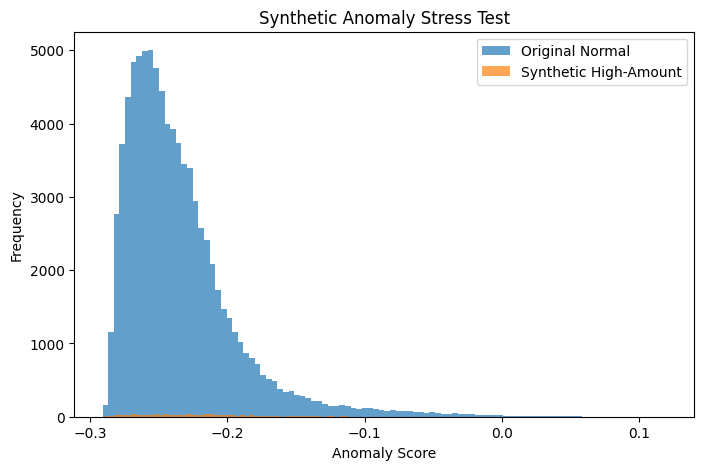

In [34]:
plt.figure(figsize=(8, 5))
plt.hist(best_scores[y_test.values == 0], bins=100, alpha=0.7, label="Original Normal")
plt.hist(synthetic_scores, bins=100, alpha=0.7, label="Synthetic High-Amount")
plt.title("Synthetic Anomaly Stress Test")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Synthetic Anomaly Stress Test

The synthetic anomaly stress test modified 1,000 normal transactions by multiplying their transaction amount by 10.

The original normal transactions had a mean anomaly score of -0.2344 and a median anomaly score of -0.2441. The synthetic high-amount transactions had a higher mean anomaly score of -0.2184 and a higher median anomaly score of -0.2267.

Because higher scores mean more anomalous, this shows that the model did react to the synthetic high-amount transactions by assigning them slightly higher anomaly scores.

However, the increase was not extremely large. This suggests that Isolation Forest is somewhat sensitive to unusual transaction amounts, but it does not rely only on `Amount`. The hidden PCA features also influence the final anomaly score.